### Shift Performance Analytics and optimization

## Task  day 2
# Understand Dataset Structure and Business Variables

This task focuses on understanding the structure of the manufacturing dataset, the meaning of each variable, and how the data relates to real production processes at NorDex.

# data dictionary explaining the dataset tables
1. Shift_Master – shift names, times, supervisors
2. Operator_Assignment – operator skills, experience, shift allocation
3. Machine_Log – machine runtime, downtime, status
4. Production_Log – units produced, defects, cycle time (main fact table)
5. Maintenance_Records – machine maintenance events
6. Quality_Control – defect types, severity, inspection results
7. Environmental_Data – temperature and humidity per shift

### Identify the dataset 
# Variable Classification:
1. Target Variable: Shift Efficiency Score
2. Numerical Features: units_produced, defect_count, cycle_time_avg, runtime_hours, downtime_minutes, temperature, humidity
3. Categorical Features: shift_name, experience_level, skill_category, machine_status, defect_type, severity
4. Timestamp Variables: start_time, end_time, date, timestamp

# Business Meaning (Mapping dataset to manufacturing process)

1. units_produced → production output
2. downtime_minutes → machine reliability
3. defect_count → quality performance
4. experience_level → operator capability
5. maintenance_flag → preventive maintenance impact
6. temperature/humidity → environmental influence

# Potential Data Quality Issues
1. Missing operator assignments
2. Machines with runtime_hours = 0
3. Duplicate production records
4. Missing environmental readings
5. Inconsistent defect naming

# Assumptions
1. All timestamps use the same timezone
2. Each machine belongs to one shift per day
3. Operator experience levels are consistent
4. Environmental readings taken regularly

### Task Day 3
## Extract Operational Manufacturing Data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error

c:\Users\hp\Downloads\Nordex-shift-optimization-system\nordex_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Connecting to the SQL manufacturing database

In [2]:
import sqlite3

conn = sqlite3.connect('shiftData.db')

shift_data = pd.read_sql("select * from ShiftPerformance", conn)
shift_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


## View Availables Table

In [3]:
shift_data.columns #1

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

# SQL queries to retrieve required records

In [4]:
query = """
SELECT
    units_produced,
    defect_count,
    cycle_time_avg,
    shift_efficiency_score
FROM ShiftPerformance;
"""

pd.read_sql(query, conn)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score
0,929,20,35.65,95.945255
1,929,20,35.65,95.945255
2,929,20,35.65,95.945255
3,929,20,35.65,95.945255
4,929,20,35.65,95.945255
...,...,...,...,...
296329,510,20,34.79,65.162771
296330,510,20,34.79,65.162771
296331,510,20,34.79,65.162771
296332,510,20,34.79,65.162771


### filter relevant production periods and machine operations.

In [5]:
query = """
SELECT *
FROM ShiftPerformance
WHERE downtime_minutes > 0
   OR maintenance_flag = 1;
"""

pd.read_sql(query, conn)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296329,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276241,Dimensional,Major,Rejected,21.6,48.6,2024-03-31 00:00:00
296330,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276242,Assembly,Minor,Rework,21.6,48.6,2024-03-31 00:00:00
296331,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276243,Surface,Minor,Accepted,21.6,48.6,2024-03-31 00:00:00
296332,3,Night,22:00:00.0000000,06:00:00.0000000,SUP_03,13650,2024-03-31,510,20,34.79,...,None,NaN,None,276244,Cosmetic,Minor,Accepted,21.6,48.6,2024-03-31 00:00:00


### Task Day 4
## Profile Manufacturing data Quality

# Analyzing  dataset dimensions.

In [6]:
shift_data.shape

(296334, 31)

### Basic Overview of the Dataset

1. Listing all the columns in the dataset
2. shape of the data
3. information about the data type of each columns
4. checking for missing values
5. checking for statistical distribution of the numeric value of our dataset 
6. checking for duplicates

# Review column data types.

In [7]:
#2 q
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

# identify missing values

In [8]:
shift_data.isnull().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

# detect duplicte records

In [9]:
### Identifying the data quality issues

# check for duplicates

shift_data.duplicated().sum()


np.int64(0)

# Analyze statistical summaries.

In [10]:
#checking the stastical distribution of the dataset
shift_data.describe()

,shift_id,production_id,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity
count,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000
mean,2.048142,6777.751567,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118
std,0.807365,3952.136116,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084
min,1.000000,1.000000,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000
25%,1.000000,3350.000000,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000
50%,2.000000,6747.000000,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000
75%,3.000000,10200.750000,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000
max,3.000000,13650.000000,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000


In [11]:
# filing the missing values
shift_data["date"] = pd.to_datetime(shift_data["date"])

shift_data= shift_data.sort_values(by="date")

#fil ling the missing values for temperature and humidity using forward fill method and then filling any remaining missing values with the mean of the respective columns
shift_data["temperature"]= shift_data["temperature"].fillna(method="ffill").fillna(shift_data['temperature'].mean())
shift_data["humidity"]=shift_data["humidity"].fillna(method="ffill").fillna(shift_data['humidity'].mean())

# fill the timestamp
shift_data["timestamp"]= shift_data["timestamp"].fillna(method="ffill")

C:\Users\hp\AppData\Local\Temp\ipykernel_11968\488824544.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["temperature"]= shift_data["temperature"].fillna(method="ffill").fillna(shift_data['temperature'].mean())
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\488824544.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["humidity"]=shift_data["humidity"].fillna(method="ffill").fillna(shift_data['humidity'].mean())
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\488824544.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["timestamp"]= shift_data["timestamp"].fillna(method="ffill")


In [12]:
# fill the categorical mainatainenace field

shift_data['issue_type'] = shift_data["issue_type"].fillna("No Issue")
shift_data['maintenance_downtime'] = shift_data["maintenance_downtime"].fillna(0)
shift_data['resolved_by'] = shift_data["resolved_by"].fillna("No Issue resolved")


shift_data = shift_data.drop(columns=["maintenance_id"])

shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

In [13]:
# fill the numerical fields with mean values
shift_data["temperature"] = shift_data["temperature"].fillna(shift_data["temperature"].median())
shift_data["humidity"] = shift_data["humidity"].fillna(shift_data["humidity"].median())
shift_data = shift_data.drop(columns=["timestamp"], errors="ignore")

shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
dtype: int64

# Identify unusual values and anomalies.
# Examine feature distributions.
# Generate initial data quality observations.

### numerical variable analysis

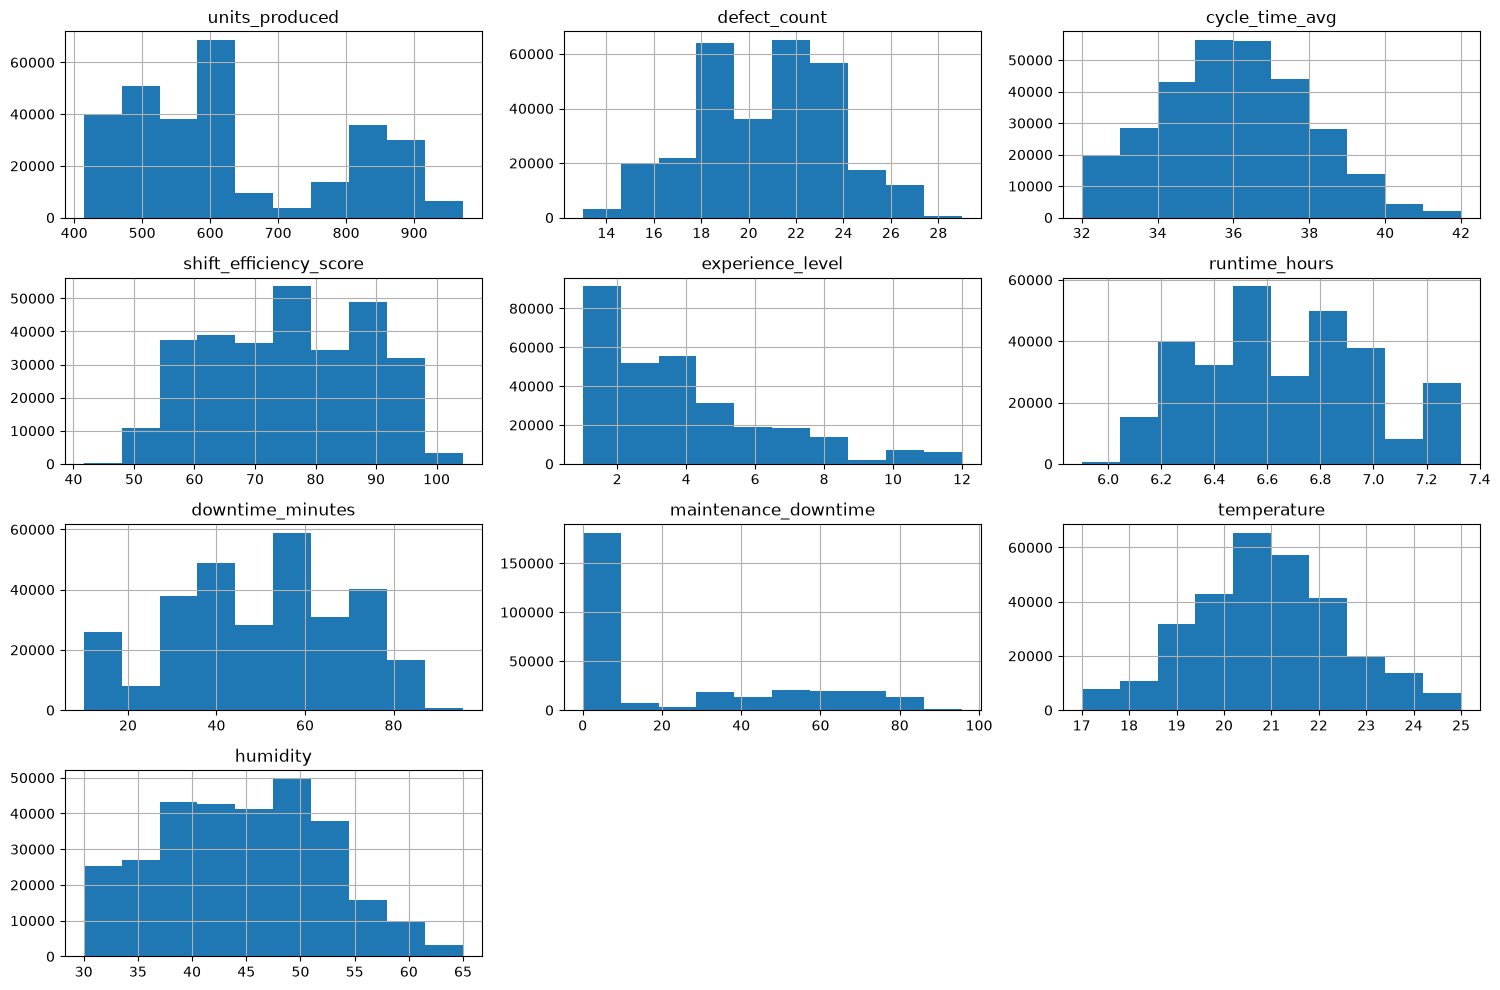

In [14]:
numerical_col= [
    "units_produced", "defect_count", "cycle_time_avg", "shift_efficiency_score","experience_level",
    "runtime_hours","downtime_minutes","maintenance_downtime","temperature", "humidity"
]

shift_data[numerical_col].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

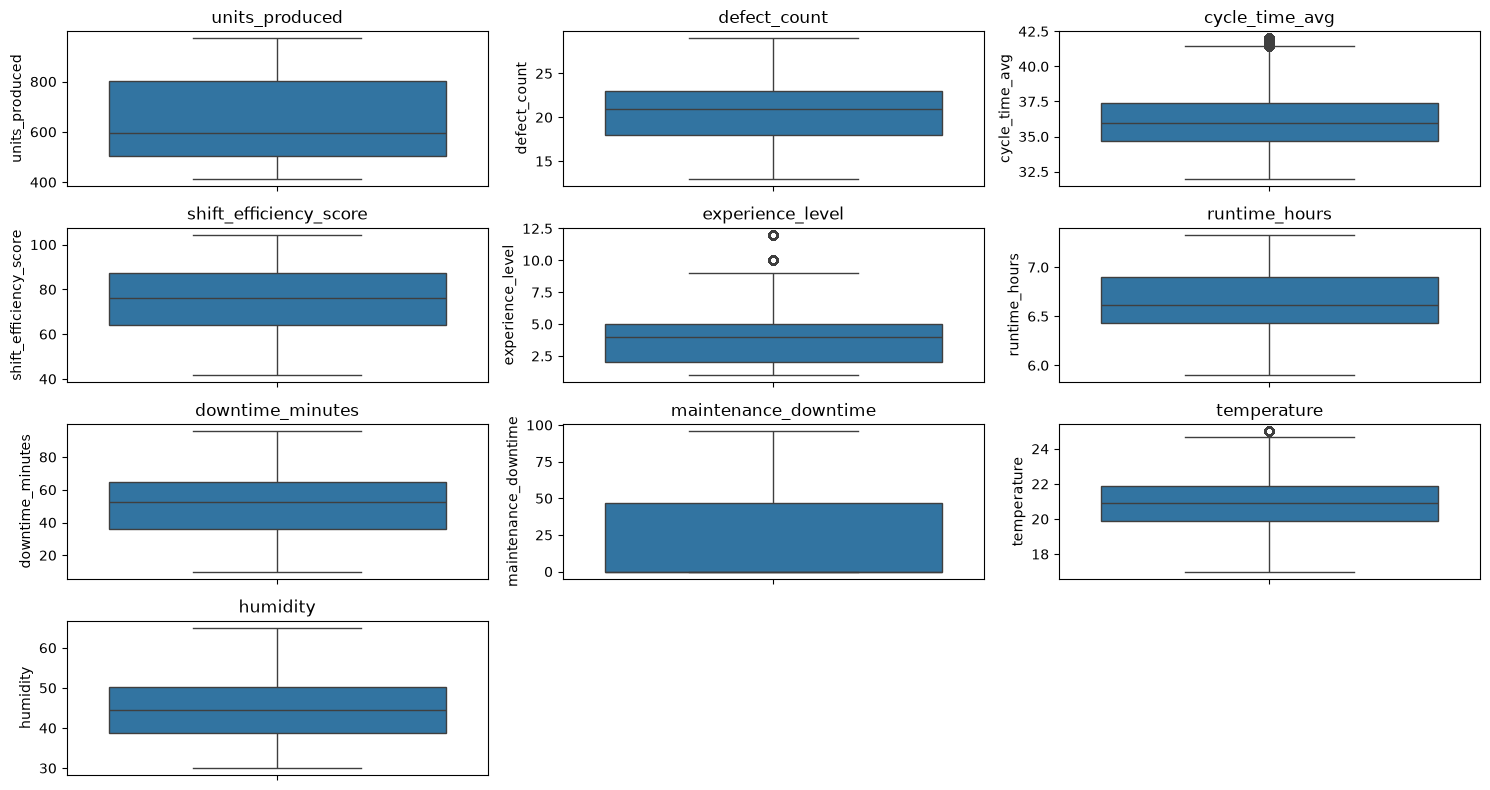

In [15]:
# using boxplot to check for outliers
plt.figure(figsize=(15, 8))

for i, columns in enumerate(numerical_col):
    plt.subplot(4, 3, i+1)
    sns.boxplot(shift_data[columns])
    plt.title(columns)

plt.tight_layout()
plt.show()

In [16]:
## categorical variable analysis
categorical_col=[
    "shift_name", "skill_category", "machine_status",
    "issue_type","defect_type","severity", "inspection_result"
]
for columns in categorical_col:
    print("value counts for each categorical columns")
    print(shift_data[columns].value_counts())

value counts for each categorical columns
shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
value counts for each categorical columns
skill_category
Intermediate    161685
Junior           56638
Senior           54664
Expert           23347
Name: count, dtype: int64
value counts for each categorical columns
machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
value counts for each categorical columns
issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
value counts for each categorical columns
defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
value counts for each categorical columns
severity
Minor       207323
Major        74329
Critical     14682
Name: count, dtype: int64
value counts for each categorical c

C:\Users\hp\AppData\Local\Temp\ipykernel_11968\756063591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=col, y='counts', palette = 'coolwarm', ax = axes[i])
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\756063591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=col, y='counts', palette = 'coolwarm', ax = axes[i])
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\756063591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=col, y='counts', palette = 'coolwarm', ax = axes[i])
C:\Users\hp\A

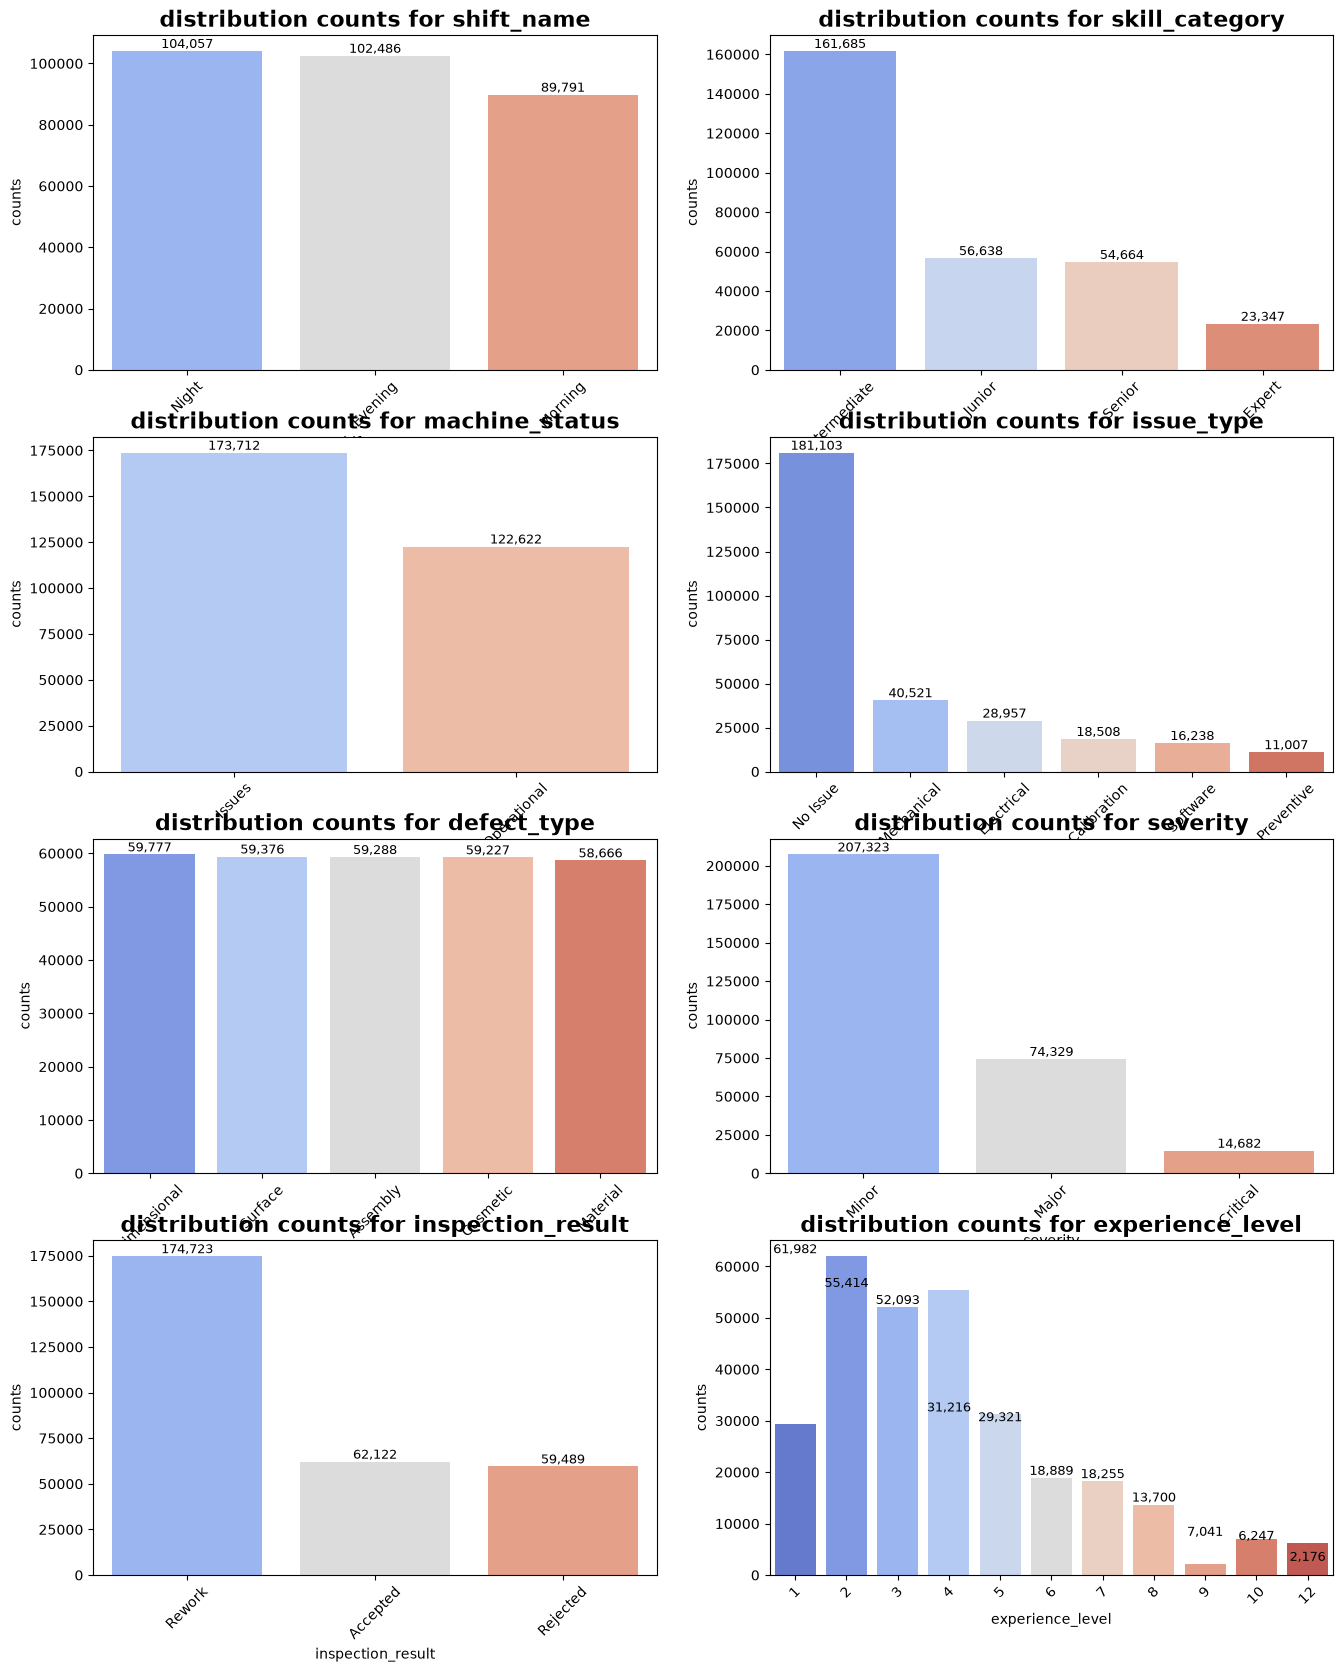

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

## categorical variable analysis
categorical_col=[
    "shift_name", "skill_category",
    "machine_status", "issue_type",
    "defect_type","severity", "inspection_result", "experience_level"
]

fig, axes =plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_col):
    counts = shift_data[col].value_counts().reset_index()
    counts.columns = [col, 'counts']

    sns.barplot(data=counts, x=col, y='counts', palette = 'coolwarm', ax = axes[i])


    axes[i].tick_params(axis='x', rotation = 45)
    axes[i].set_title(f"distribution counts for {col}", fontsize=16, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('counts')

    for j, v in enumerate(counts['counts']):
        axes[i].text(j, v, f'{v:,}', ha= 'center', va='bottom', fontsize=9)

plt.tight_layout
plt.show()

# Generate initial data quality observations

1. Units produced is right‑skewed, meaning most shifts produce low to medium quantities while a few produce very high output.
2. Downtime_minutes shows a long tail, indicating some extreme downtime events that may be outliers.
3. Temperature and humidity follow normal‑like distributions, suggesting stable environmental conditions.
4. Maintenance_downtime is mostly zero, confirming that maintenance events are rare.
5. Shift_efficiency_score clusters around mid‑range values, showing consistent performance across shifts.

### Task Day 5
## Clean and Prepare Manufacturing Data
# note: most of task 5 has been done in task 1 to 4 

In [18]:
#remove duplicates
shift_data = shift_data.drop_duplicates()

In [19]:
# exporting clean dataset and done with data preprocessing
shift_data.to_csv("cleaned_shift_data_v1.csv", index=False)

## week 2 Task 1

# Analyze Manufacturing Performance Patterns 

## Maintenance Flag Analysis
Analyzing downtime behaviour 

## Exploratory Data analysis 
in thsi task we explore the manufacturing dataset and identify patterns, relationships and operational factors that affect the production efficiency .

In [20]:
maintenance_grouped = shift_data.groupby("maintenance_flag")[numerical_col].mean()

maintenance_grouped

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,4.141962,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,3.688321,6.600786,53.954773,53.701075,20.860356,44.613007


In [21]:
maintenance_grouped_plot = maintenance_grouped.reset_index()
maintenance_grouped_plot

,maintenance_flag,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
0,0,641.509524,20.593933,36.016664,76.106388,4.141962,6.678512,49.281488,13.520254,20.900962,44.572548
1,1,604.139302,20.998291,36.026591,73.053327,3.688321,6.600786,53.954773,53.701075,20.860356,44.613007


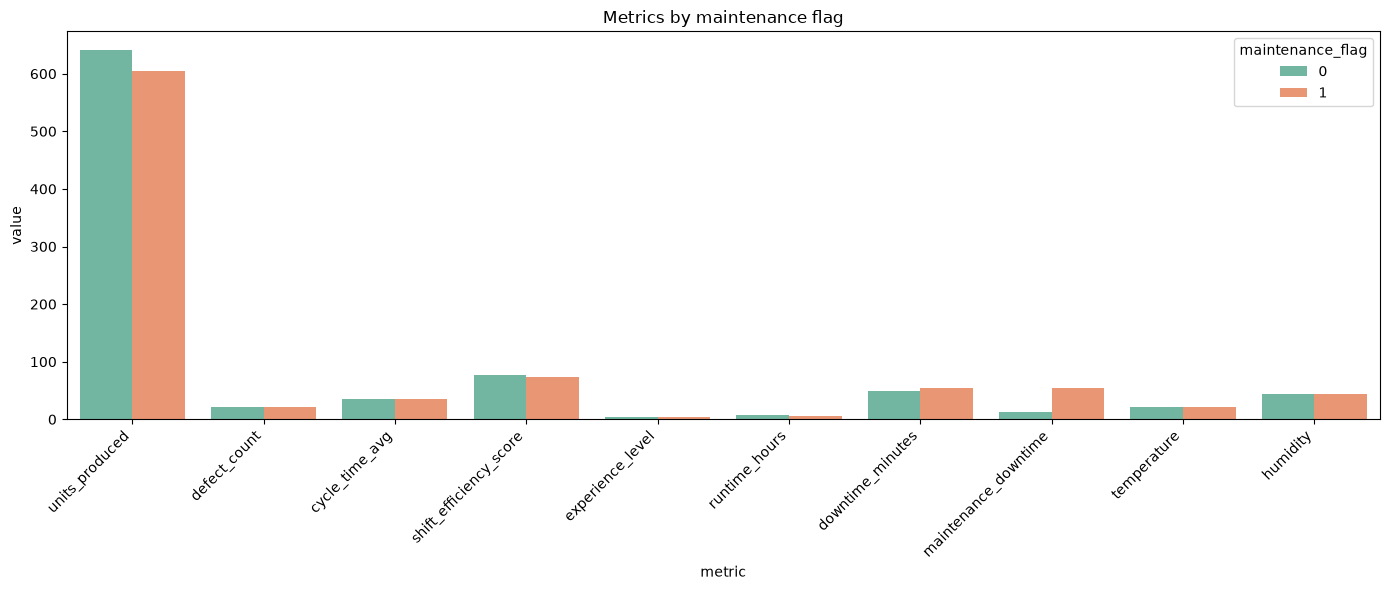

In [22]:
maintenance_grouped_melt =maintenance_grouped_plot.melt(
    id_vars = ['maintenance_flag'],
    var_name= 'metric',
    value_name= 'value'

)

plt.figure(figsize=(14, 6))

sns.barplot(data = maintenance_grouped_melt, x='metric', y='value', hue='maintenance_flag', palette='Set2')

plt.xticks(rotation=45, ha='right')
plt.title('Metrics by maintenance flag')
plt.legend(title='maintenance_flag')
plt.tight_layout()
plt.show()

### shift performance analysis 
# investigating the machine performance

In [23]:
shift_kpi =shift_data.groupby("shift_name").agg({
    "units_produced":["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": ["mean", "sum"],
    "downtime_minutes":["mean", "sum"],
    "shift_efficiency_score": "mean"

}).reset_index()

shift_kpi.columns = ['shift_name', 'average_units_produced', 'total_unit_produced', 'average_cycle_time', 
'average_defect_counts', 'total_defect_counts', 'average_downtime_minutes',
 'total_downtime_minutes','average_shift_efficiency_score'  
              ]

shift_kpi

,shift_name,average_units_produced,total_unit_produced,average_cycle_time,average_defect_counts,total_defect_counts,average_downtime_minutes,total_downtime_minutes,average_shift_efficiency_score
0,Evening,601.050543,61599266,36.025551,21.329079,2185932,50.569570,5182672.96,76.737957
1,Morning,846.926073,76046339,35.999287,18.749151,1683505,29.086002,2611661.18,90.869944
2,Night,484.765119,50443204,36.028043,21.670998,2255019,67.857893,7061088.73,61.164965


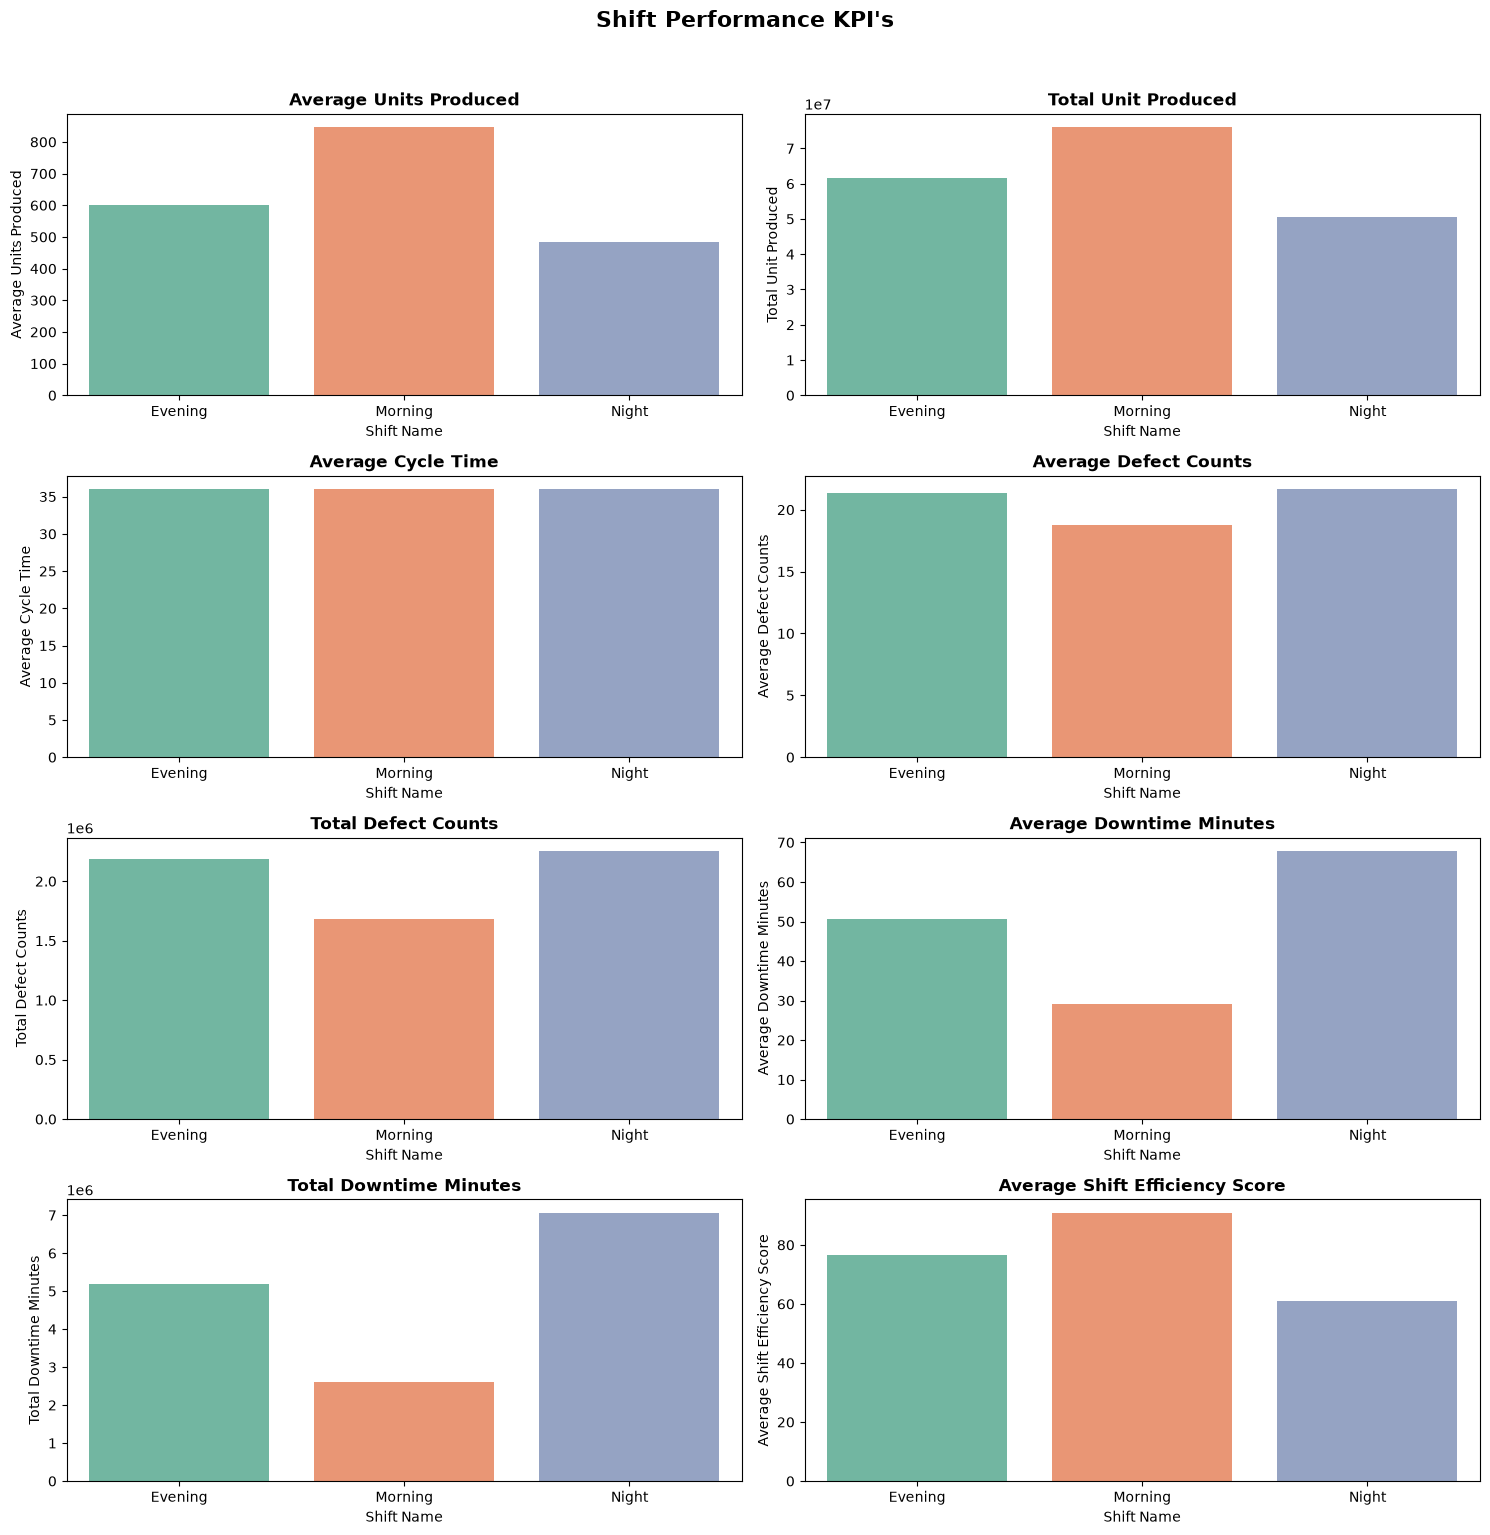

In [24]:
fig, axes =plt.subplots(4, 2, figsize=(15, 15))

axes = axes.flatten()
metrics =['average_units_produced', 'total_unit_produced', 'average_cycle_time', 
          'average_defect_counts', 'total_defect_counts', 'average_downtime_minutes',
          'total_downtime_minutes','average_shift_efficiency_score'  
          ]

for i , metric in enumerate(metrics):
    sns.barplot(data=shift_kpi, x='shift_name', y= metric,
                hue = 'shift_name', palette ='Set2', legend =False, ax=axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Shift Name')
    axes[i].set_ylabel(metric.replace("_", " ").title())


# add a value label tot he bar
for j, v in enumerate(shift_kpi[metric]):
    if 'units' in metric:
        axes[i].text(j, v, f'{v:0f}', ha ='center', va= 'bottom')

plt.suptitle("Shift Performance KPI's", fontsize=16, fontweight= 'bold', y=1.02)
plt.tight_layout()
plt.show()



# Analyzing the downtime behaviour

# production output

In [25]:
shift_data["total_machine_hours"] = shift_data["runtime_hours"] + (shift_data["downtime_minutes"]/60)

output_per_hour =(
    shift_data.groupby("shift_name").apply(lambda x: x["units_produced"].sum() / x["total_machine_hours"].sum())
    .rename("output_per_hour")
)

output_per_hour

C:\Users\hp\AppData\Local\Temp\ipykernel_11968\3356752664.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shift_data.groupby("shift_name").apply(lambda x: x["units_produced"].sum() / x["total_machine_hours"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

TO DO
CREATE A pie chart to visualise the ouput per hour metrics

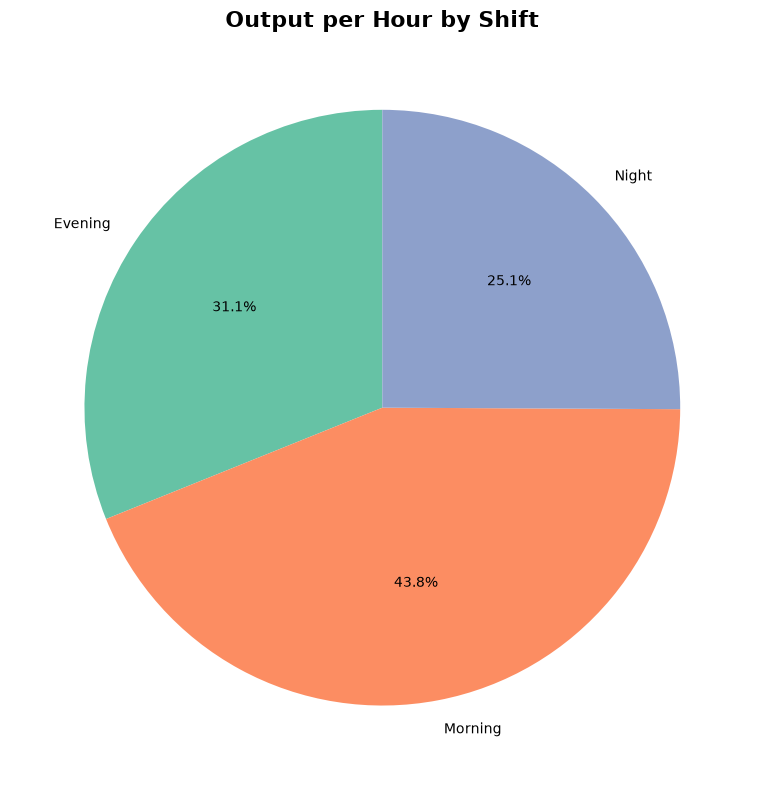

In [26]:
# creating a pie chart to visualize the output per hour metric for each shift
plt.figure(figsize=(8, 8))
plt.pie(output_per_hour, labels=output_per_hour.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title("Output per Hour by Shift", fontsize=16, fontweight='bold')   
plt.tight_layout()
plt.show()

Availabitity Analysis

In [27]:
availability = (
    shift_data.groupby("shift_name").apply(lambda x: x["runtime_hours"].sum() / (x["runtime_hours"].sum() + x["downtime_minutes"].sum()/60))
    .rename("availability")
)
availability

C:\Users\hp\AppData\Local\Temp\ipykernel_11968\2837302895.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shift_data.groupby("shift_name").apply(lambda x: x["runtime_hours"].sum() / (x["runtime_hours"].sum() + x["downtime_minutes"].sum()/60))


shift_name
Evening    0.887622
Morning    0.935362
Night      0.849205
Name: availability, dtype: float64

# study defect patterns

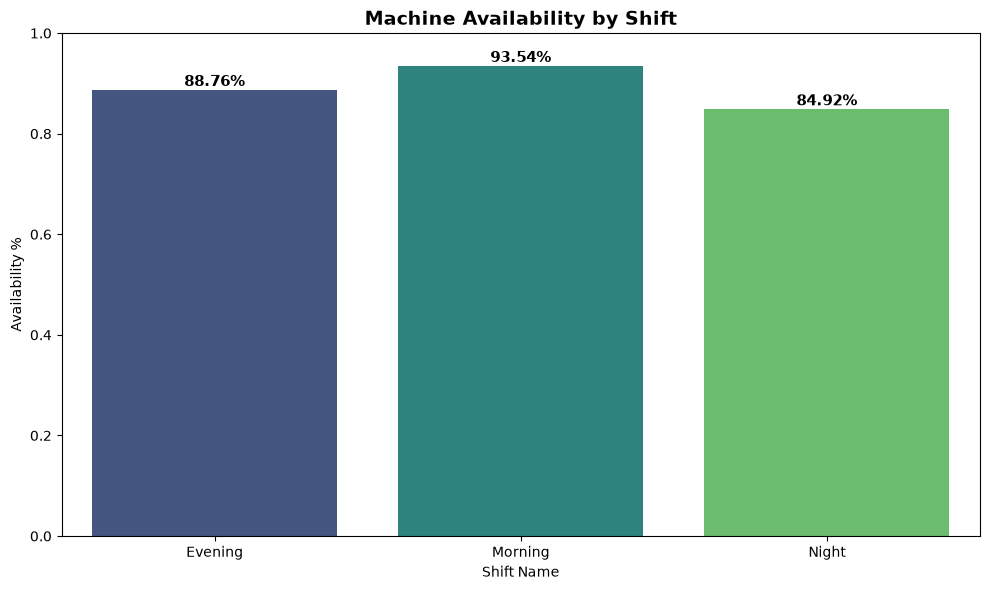

In [28]:
availability_df = pd.DataFrame(availability).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=availability_df, x='shift_name', y='availability', hue='shift_name', palette='viridis', legend=False)

plt.title('Machine Availability by Shift', fontsize=14, fontweight='bold')
plt.xlabel('Shift Name')
plt.ylabel('Availability %')

plt.ylim(0, 1)

for i, v in enumerate(availability_df['availability']):
    plt.text(i, v, f'{v:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

A Detailed breakdown of what is happening:

A simple scenerio breakdown of the OEE code and why it is important:


# COde Breakdown>: A Factory story

met our factory
imagaine you run a bottle factory .each machine shpould produce 100 botteles per hourbn(theoretical rate). each shift is  7.5hrs(planned time)


# first code block: organising the data
scenerio : u have a mesy noteb ook with all ur factory records mixed together
prod=(
    df[['prodution_iod, hsiftid,date,munitsproduced,defect count,]]
    .drop dyuplicate (subset=[production-id])
    .copy()
)


#what happneing : you create a clean prodution logistic shows
' how mny bottls were made
how many were defective
one entry per production run ( no duplicate)



mach = 9 
df[['machine-id, shift id, date , downtime]]


In [29]:
#prodcution data
production = (shift_data[['production_id', 'shift_id','date','units_produced','defect_count']]
.drop_duplicates(subset=['production_id'])  
.copy())

#machine label data
machine = (
    shift_data[['machine_id','shift_id', 'date', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)


In [30]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [31]:
machine.shape

(13650, 4)

In [32]:
machine.head()

,machine_id,shift_id,date,downtime_minutes
0,MC_001,1,2024-01-01,15.39
2308,MC_002,3,2024-01-01,53.73
2309,MC_003,3,2024-01-01,51.90
2331,MC_004,3,2024-01-01,54.45
2281,MC_001,3,2024-01-01,52.99


In [33]:
production.shape

(13650, 5)

# Calculate manufacturing KPIs 
# OEE

In [34]:
import os
planned = globals().get('planned_H', 7.5)
theoretical_rate= globals().get('theoretical_rate', 100.0)

machine['available_machine']=1-(machine['downtime_minutes']/(planned*60))
machine['available_machine']= machine['available_machine'].clip(lower=0, upper=1)

# aggregating availability per shift and data
availability_aggregate = (
    machine.groupby(['shift_id', 'date'])['available_machine'].mean()
.reset_index()
.rename(columns={'available_machine': 'availability'})
)


#merge availability_aggregate with production data
merged_production_data = production.merge(availability_aggregate, on=['shift_id', 'date'], how='left')
merged_production_data['availability'] = merged_production_data['availability'].fillna(1)

#performance ratio calculaiton
merged_production_data['performance'] = (merged_production_data['units_produced'] / (theoretical_rate * planned)).clip(lower=0, upper=1)

#quality ratio calculation
merged_production_data['quality'] = 1-merged_production_data['defect_count'] / merged_production_data['units_produced']
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(lower=0, upper=1)

merged_production_data['oee_estimate'] = merged_production_data['availability'] * merged_production_data['performance'] * merged_production_data['quality']


In [35]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,availability,performance,quality,oee_estimate
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.942940
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.598453
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.549072
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.594926
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.627846


In [36]:
merged_production_data['month'] = merged_production_data['date'].dt.month

monthly_oee = (merged_production_data.groupby('month')['oee_estimate'].mean().reset_index()
)
monthly_oee = monthly_oee.set_index("month")["oee_estimate"]

In [37]:
monthly_oee.head()

month
1    0.748962
2    0.685324
3    0.688293
Name: oee_estimate, dtype: float64

In [38]:
for month, value in monthly_oee.items():
    print(f"Month: {month}:  OEE Estimate:{value*100:.2f}%")

if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    oee_degradation = ((m1 - m3) / m1) * 100
    print(f"OEE Degradation from January to March : {oee_degradation:.2f}%")

else:
    print("OEE degradation calculations require data for both January and March.")

Month: 1:  OEE Estimate:74.90%
Month: 2:  OEE Estimate:68.53%
Month: 3:  OEE Estimate:68.83%
OEE Degradation from January to March : 8.10%


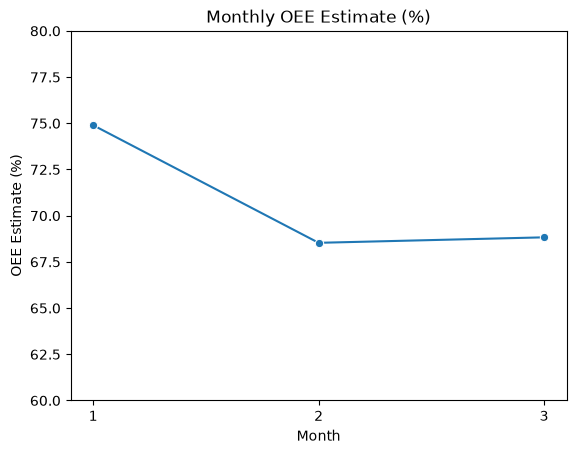

In [39]:
monthly_oee= monthly_oee.reset_index()
monthly_oee["oee_percentage"] = monthly_oee["oee_estimate"] * 100

sns.lineplot(data=monthly_oee, x='month', y='oee_percentage', marker='o')
plt.title('Monthly OEE Estimate (%)')
plt.ylabel('OEE Estimate (%)')
plt.ylim(60, 80)
plt.xticks([1, 2, 3])
plt.xlabel('Month')
plt.show()

# Explore relationships between operational variables

Text(0.5, 1.0, 'Correlation between the downtime, defect, output and runtime variables')

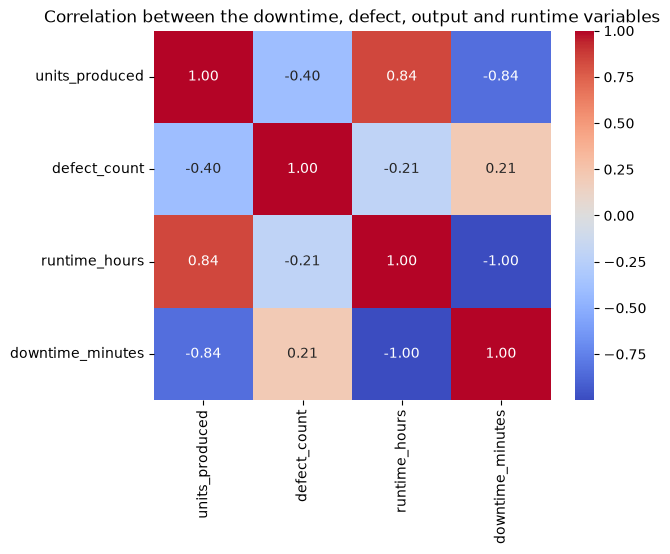

In [41]:
### correlation analysis

corr_focus = shift_data[['units_produced', 'defect_count', 'runtime_hours', 'downtime_minutes']].corr()
sns.heatmap(corr_focus, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between the downtime, defect, output and runtime variables")

C:\Users\hp\AppData\Local\Temp\ipykernel_11968\1340495562.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shift_data, x='experience_level', y= 'defect_count', palette='Set2')


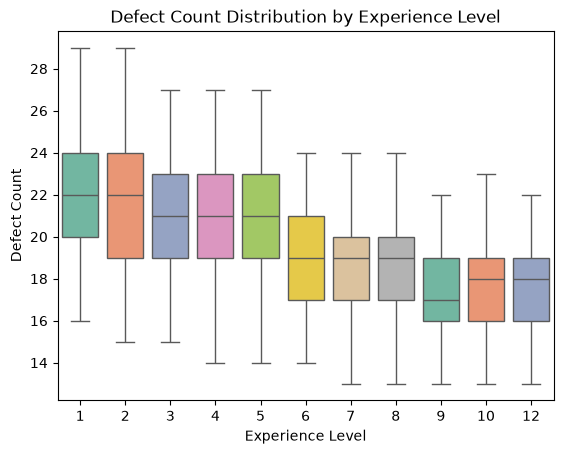

In [42]:
sns.boxplot(data=shift_data, x='experience_level', y= 'defect_count', palette='Set2')
plt.title("Defect Count Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Defect Count")
plt.show()

## fEATURE Engineering ( creating new features)

In [43]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  object        
 3   end_time                296334 non-null  object        
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [44]:
# paring data
shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])

# fixing overnight shifts where end time is less than start time
mask = shift_data['end_time'] < shift_data['start_time']
shift_data.loc[mask, 'end_time'] =shift_data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

# 1. shift duration in hours
shift_data['shift_duration'] = (shift_data['end_time'] - shift_data['start_time']).dt.total_seconds() / 3600

# defect rate calculation
shift_data['defect_rate'] = shift_data['defect_count'] / shift_data['units_produced']

# downtime ratio calculation
shift_data['downtime_ratio'] = shift_data['downtime_minutes'] / (shift_data['shift_duration'] * 60)

# temporal feature features
shift_data['day_of_week'] = shift_data['date'].dt.dayofweek
shift_data['hour_of_day'] = shift_data['start_time'].dt.hour

shift_data.head()


C:\Users\hp\AppData\Local\Temp\ipykernel_11968\2141481427.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\2141481427.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])
C:\Users\hp\AppData\Local\Temp\ipykernel_11968\2141481427.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  shift_data.loc[mask, 'end_time'] =shift_data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,severity,inspection_result,temperature,humidity,total_machine_hours,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,1,Morning,2026-08-12 06:00:00,2026-08-12 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,3,Night,2026-08-12 22:00:00,2026-08-13 06:00:00,SUP_03,102,2024-01-01,530,21,35.61,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,3,Night,2026-08-12 22:00:00,2026-08-13 06:00:00,SUP_03,103,2024-01-01,489,22,34.01,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,3,Night,2026-08-12 22:00:00,2026-08-13 06:00:00,SUP_03,103,2024-01-01,489,22,34.01,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,3,Night,2026-08-12 22:00:00,2026-08-13 06:00:00,SUP_03,103,2024-01-01,489,22,34.01,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [45]:
shift_data.shape

(296334, 35)

## Feature Selection 

In [52]:
shift_data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'issue_type', 'maintenance_downtime', 'resolved_by',
       'qc_id', 'defect_type', 'severity', 'inspection_result', 'temperature',
       'humidity', 'total_machine_hours', 'shift_duration', 'defect_rate',
       'downtime_ratio', 'day_of_week', 'hour_of_day'],
      dtype='object')

In [47]:
shift_data['shift_efficiency_score']

0         95.945255
2308      66.604731
2309      61.238523
2310      61.238523
2311      61.238523
            ...    
294258    64.948418
294259    64.948418
294260    64.948418
294238    78.816910
296333    65.162771
Name: shift_efficiency_score, Length: 296334, dtype: float64

In [53]:
col_to_drop = [
#identifiers
    'shift_id', 'production_id', 'machine_id', 'supervisor_id', 'qc_id', 'operator_id', 'operator_name',

    # audit field
    'resolved_by',

    # raw datetime format columns
    'start_time', 'end_time', 'date', 'shift_duration', 'downtime_ratio',

    #columns I dropped 
    'shift_name','defect_type','issue_type','inspection_result','severity','skill_category','shift_duration', 
    'defect_rate','downtime_ratio','total_machine_hours'
    ]

## colums i dropped and why 
1. shift_name  - This is just the name of the shift. Names don’t affect how efficient a shift is.

2. defect_type -This tells you what kind of defect happened, not how many. The model learns better from the actual defect count.

3. issue_type - A text description of a problem. It doesn’t give measurable information the model can use.

4. inspection_result - A pass/fail label. Efficiency is already captured through numbers like defect_count.

5. severity - A text description of how serious a defect is. The model learns better from numeric defect data.

6. skill_category - A broad label like “Beginner” or “Advanced”. We already have a clearer numeric feature: experience_level.

7. shift_duration - This repeats information already found in runtime_hours and downtime_minutes.

8. defect_rate  - This is calculated from defect_count and units_produced. Keeping both creates duplicate information.

9. downtime_ratio  - This is calculated from downtime_minutes and runtime_hours. The raw values are more useful.

10. total_machine_hours - This overlaps with runtime_hours and maintenance_downtime, so it doesn’t add new value.

In [54]:
shift_data.drop(columns= col_to_drop, inplace=True)

In [55]:
shift_data.shape

(296334, 14)

In [56]:
shift_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_downtime,temperature,humidity,day_of_week,hour_of_day
0,929,20,35.65,95.945255,7,7.24,15.39,0,Operational,0.0,22.3,49.9,0,6
2308,530,21,35.61,66.604731,5,6.60,53.73,0,Issues,0.0,22.3,49.9,0,22
2309,489,22,34.01,61.238523,2,6.64,51.90,0,Issues,0.0,22.3,49.9,0,22
2310,489,22,34.01,61.238523,2,6.64,51.90,0,Issues,0.0,22.3,49.9,0,22
2311,489,22,34.01,61.238523,2,6.64,51.90,0,Issues,0.0,22.3,49.9,0,22


In [57]:
shift_data.duplicated().sum()

np.int64(281692)

In [58]:
shift_data.drop_duplicates(inplace=True)

In [59]:
shift_data.duplicated().sum()

np.int64(0)

In [60]:
shift_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_downtime,temperature,humidity,day_of_week,hour_of_day
0,929,20,35.65,95.945255,7,7.24,15.39,0,Operational,0.00,22.3,49.9,0,6
2308,530,21,35.61,66.604731,5,6.60,53.73,0,Issues,0.00,22.3,49.9,0,22
2309,489,22,34.01,61.238523,2,6.64,51.90,0,Issues,0.00,22.3,49.9,0,22
2331,527,21,38.87,65.059835,4,6.59,54.45,1,Issues,54.45,22.3,49.9,0,22
2281,555,21,35.64,66.953888,2,6.62,52.99,0,Issues,0.00,22.3,49.9,0,22


## Modelling Section

In [61]:
x = shift_data.drop(columns=['shift_efficiency_score'], axis=1)
y = shift_data['shift_efficiency_score']

In [62]:
x.head()

,units_produced,defect_count,cycle_time_avg,experience_level,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_downtime,temperature,humidity,day_of_week,hour_of_day
0,929,20,35.65,7,7.24,15.39,0,Operational,0.00,22.3,49.9,0,6
2308,530,21,35.61,5,6.60,53.73,0,Issues,0.00,22.3,49.9,0,22
2309,489,22,34.01,2,6.64,51.90,0,Issues,0.00,22.3,49.9,0,22
2331,527,21,38.87,4,6.59,54.45,1,Issues,54.45,22.3,49.9,0,22
2281,555,21,35.64,2,6.62,52.99,0,Issues,0.00,22.3,49.9,0,22


In [63]:
y.head()

0       95.945255
2308    66.604731
2309    61.238523
2331    65.059835
2281    66.953888
Name: shift_efficiency_score, dtype: float64

In [80]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [85]:
numerical_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [86]:
numerical_cols

['units_produced',
 'defect_count',
 'cycle_time_avg',
 'experience_level',
 'runtime_hours',
 'downtime_minutes',
 'maintenance_flag',
 'maintenance_downtime',
 'temperature',
 'humidity',
 'day_of_week',
 'hour_of_day']

In [87]:
categorical_cols

['machine_status']

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [73]:
import dagshub
dagshub.init(repo_owner='aleyiboogooluwamary', repo_name='Nordex-shift-optimization-system', mlflow=True)

Initialized MLflow to track repo "aleyiboogooluwamary/Nordex-shift-optimization-system"

Repository aleyiboogooluwamary/Nordex-shift-optimization-system initialized!

In [89]:
import mlflow
import mlflow.sklearn
import dagshub

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [93]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

results = []
fitted_pipeline = {}

mlflow.set_experiment("Nordex_shift_optimization_Models")

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

        # training the model
        # rebuild preprocessor from actual training columns to avoid missing-target column errors
        num_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
        local_preprocessor = ColumnTransformer(
            transformers=[
            ('numerical', StandardScaler(), num_cols),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ]
        )
        pipeline = Pipeline(steps=[('preprocessor', local_preprocessor), ('model', model)])
        pipeline.fit(x_train, y_train)

        # making predictions on the test set
        y_pred = pipeline.predict(x_test)

        # evaluating the model
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        fitted_pipeline[model_name] = pipeline
        results.append({
            "model": model_name,
            "mae": mae,
            "mse": mse,
            "r2": r2
        })

        # logging metrics and parameters to MLflow 
        mlflow.log_param("model", model_name)

        if hasattr(model, 'get_params'):
            for param_key, param_value in model.get_params().items():
                mlflow.log_param(param_key, param_value)

        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("r2", r2)

        # logging the model to MLflow
        mlflow.sklearn.log_model(pipeline, artifact_path=model_name)

        print(f"Model: {model_name}, MAE: {mae:.4f}, MSE: {mse:.4f}, R2 Score: {r2:.4f}")


2026/08/12 10:01:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model: LinearRegression, MAE: 3.2168, MSE: 16.2587, R2 Score: 0.9046
🏃 View run LinearRegression at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0/runs/6419b3c9be90443f8726411644663bdc
🧪 View experiment at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0


2026/08/12 10:02:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model: RandomForest, MAE: 2.3583, MSE: 9.1979, R2 Score: 0.9460
🏃 View run RandomForest at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0/runs/fce99c1c6352412895b38338354a5012
🧪 View experiment at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0


2026/08/12 10:05:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model: GradientBoosting, MAE: 2.3970, MSE: 9.0177, R2 Score: 0.9471
🏃 View run GradientBoosting at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0/runs/10a49dc00b744d89a5a9b9f683ee5885
🧪 View experiment at: https://dagshub.com/aleyiboogooluwamary/Nordex-shift-optimization-system.mlflow/#/experiments/0
